In [12]:
import os, json, math, time, random
from collections import Counter, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import sqlite3

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

NET_DIR = "outputs_networks_v1"
PERSONA_DIR = "outputs_personas_v3"
MANIFEST_PATH = os.path.join(NET_DIR, "networks_manifest.json")

NELA_DB_PATH = os.path.join("nela", "nela-gt-2021.db")
NELA_LABELS_PATH = os.path.join("nela", "labels_2021.csv")

OUT_DIR = "outputs_weng_replication_v2"
os.makedirs(OUT_DIR, exist_ok=True)

CFG = {
    "n_events": 250000,
    "alpha": 10,
    "mu": 0.02,
    "recency_beta": 1.3,
    "attention_sweep": [5, 10, 20, 40],
    "n_runs_per_setting": 3,

    "graphs_to_compare": ["activity_homophily", "degree_randomized", "influence_biased"],

    "n_items_pool": 200000,
    "min_text_len": 120,

    "sample_edges_for_debug": 20000
}

In [2]:
with open(MANIFEST_PATH, "r") as f:
    manifest = json.load(f)

AGENTS_FILE = manifest["agents_file"]
graphs = manifest["graphs"]

def load_graph_from_parquet(path):
    edf = pd.read_parquet(path)
    G = nx.Graph()
    for r in edf.itertuples(index=False):
        u, v = r.src, r.dst
        if u == v:
            continue
        if not G.has_edge(u, v):
            G.add_edge(u, v)
    return G

G_map = {}
for name, fname in graphs.items():
    G_map[name] = load_graph_from_parquet(os.path.join(NET_DIR, fname))

agents_path = os.path.join(PERSONA_DIR, AGENTS_FILE)
with open(agents_path) as f:
    agents = json.load(f)

rows = []
for a in agents:
    aid = a.get("agent_id")
    st = a.get("state", {})
    beh = a.get("behavior", {})
    b = st.get("belief_vector", [0.0, 0.0])
    rows.append({
        "agent_id": aid,
        "comments_per_day": float(beh.get("comments_per_day", 0.0)),
        "belief0": float(b[0]) if len(b) > 0 else 0.0,
        "belief1": float(b[1]) if len(b) > 1 else 0.0
    })

A = pd.DataFrame(rows).dropna(subset=["agent_id"])
A["comments_per_day"] = pd.to_numeric(A["comments_per_day"], errors="coerce").fillna(0.0)

{k: (v.number_of_nodes(), v.number_of_edges()) for k, v in G_map.items()}, A.shape

({'activity_homophily': (2000, 21117),
  'degree_randomized': (2000, 21117),
  'influence_biased': (2000, 26904)},
 (2000, 4))

In [3]:
def intersect_nodes(G, A):
    gnodes = set(G.nodes())
    A2 = A[A["agent_id"].isin(gnodes)].copy()
    G2 = G.subgraph(A2["agent_id"].tolist()).copy()
    return G2, A2

base_name = CFG["graphs_to_compare"][0]
for name in CFG["graphs_to_compare"]:
    G_map[name], _tmp = intersect_nodes(G_map[name], A)

A = A[A["agent_id"].isin(set(G_map[base_name].nodes()))].copy()
A = A.reset_index(drop=True)

agent_ids = A["agent_id"].tolist()

cpd = np.clip(A["comments_per_day"].to_numpy(dtype=float), 0.0, None)
rank = pd.Series(cpd).rank(pct=True).to_numpy(dtype=float)

act_w = 0.05 + 0.95 * rank
act_w = act_w / act_w.sum()

agent_ids[:3], act_w[:3].sum()

(['deebaggus', 'ztoundas', 'jimbob0i0'], np.float64(0.0019528546609866968))

In [4]:
con = sqlite3.connect(NELA_DB_PATH)

def load_item_ids(conn, n_items=200000, min_text_len=120):
    cur = conn.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [r[0] for r in cur.fetchall()]

    best = None
    for t in tables:
        try:
            cur.execute(f"PRAGMA table_info({t});")
            cols = [r[1] for r in cur.fetchall()]
            cset = set([c.lower() for c in cols])
            if ("title" in cset or "headline" in cset) and ("content" in cset or "text" in cset or "body" in cset or "article" in cset):
                best = (t, cols)
                break
        except Exception:
            continue

    if best is None:
        raise RuntimeError("Could not find a suitable NELA table with title+text/content columns.")

    table, cols = best
    col_l = {c.lower(): c for c in cols}

    id_col = None
    for k in ["id", "doc_id", "article_id", "story_id", "item_id", "url"]:
        if k in col_l:
            id_col = col_l[k]
            break

    text_col = None
    for k in ["content", "text", "body", "article", "full_text"]:
        if k in col_l:
            text_col = col_l[k]
            break

    if text_col is None:
        raise RuntimeError("No text column found in selected NELA table.")

    if id_col is None:
        id_expr = "rowid AS item_id"
    else:
        id_expr = f"{id_col} AS item_id"

    q = f"""
    SELECT {id_expr}
    FROM {table}
    WHERE {text_col} IS NOT NULL
      AND length({text_col}) >= {int(min_text_len)}
    LIMIT {int(n_items)}
    """
    df = pd.read_sql_query(q, conn)
    ids = df["item_id"].astype(str).tolist()
    return ids

item_pool = load_item_ids(con, n_items=CFG["n_items_pool"], min_text_len=CFG["min_text_len"])
len(item_pool), item_pool[:3]

(200000,
 ['activistpost--2021-01-01--Why You Should Expect More Stimulus Fraud Coming Soon',
  'activistpost--2021-01-01--Taylor Hudak Interview – The Political Persecution Of Julian Assange & The War On Journalism',
  'bbc--2021-01-01--Moscow train carriage helps rehome stray pets'])

In [13]:
def run_weng_like(G, agent_ids, act_w, item_pool, n_events, alpha, mu, recency_beta=1.3, seed=7):
    rng = np.random.default_rng(seed)

    neigh = {u: list(G.neighbors(u)) for u in agent_ids}
    screens = {u: deque(maxlen=alpha) for u in agent_ids}

    pool = list(item_pool)
    rng.shuffle(pool)
    pool_ptr = 0

    on_screens = Counter()
    births = {}
    deaths = {}
    popularity = Counter()

    def inject_to(v, meme, t):
        q = screens[v]
        if len(q) == alpha:
            old = q[0]
        else:
            old = None

        q.append(meme)

        if old is not None and old != meme:
            on_screens[old] -= 1
            if on_screens[old] == 0 and old in births and old not in deaths:
                deaths[old] = t

        on_screens[meme] += 1

    def new_meme():
        nonlocal pool_ptr
        if pool_ptr >= len(pool):
            pool_ptr = 0
            rng.shuffle(pool)
        m = pool[pool_ptr]
        pool_ptr += 1
        return m

    for t in range(n_events):
        u = rng.choice(agent_ids, p=act_w)

        if rng.random() < mu:
            m = new_meme()
            if m not in births:
                births[m] = t
        else:
            if len(screens[u]) == 0:
                m = new_meme()
                if m not in births:
                    births[m] = t
            else:
                q = list(screens[u])
                k = len(q)
                idx = np.arange(k)
                w = (idx + 1) ** float(recency_beta)
                w = w / w.sum()
                m = q[rng.choice(idx, p=w)]

        popularity[m] += 1

        inject_to(u, m, t)
        for v in neigh[u]:
            inject_to(v, m, t)

    for m in list(births.keys()):
        if m not in deaths:
            deaths[m] = n_events

    lifetimes = []
    pops = []
    for m in births.keys():
        if m in popularity:
            pops.append(popularity[m])
            lifetimes.append(deaths[m] - births[m])

    return {
        "popularity": np.array(pops, dtype=int),
        "lifetime": np.array(lifetimes, dtype=int),
        "births": births,
        "deaths": deaths,
        "on_screens": on_screens
    }

In [14]:
def plot_ccdf_loglog(x, title, xlabel, out_path=None):
    x = np.asarray(x, dtype=float)
    x = x[x > 0]
    if len(x) == 0:
        return
    xs = np.sort(x)
    ys = 1.0 - np.arange(1, len(xs) + 1) / len(xs)

    plt.figure(figsize=(7, 5))
    plt.plot(xs, ys, linewidth=1.5)
    plt.xscale("log")
    plt.yscale("log")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("CCDF")
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=220)
    plt.show()

def plot_logbinned_pdf(x, title, xlabel, out_path=None, bins=35):
    x = np.asarray(x, dtype=float)
    x = x[x > 0]
    if len(x) == 0:
        return
    lo = max(1.0, np.quantile(x, 0.01))
    hi = np.quantile(x, 0.999)
    if hi <= lo:
        hi = x.max()

    edges = np.logspace(np.log10(lo), np.log10(hi + 1e-12), bins)
    hist, edges = np.histogram(x, bins=edges, density=True)
    mids = np.sqrt(edges[:-1] * edges[1:])

    plt.figure(figsize=(7, 5))
    plt.plot(mids, hist, marker="o", linewidth=1.5)
    plt.xscale("log")
    plt.yscale("log")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("density (log-binned)")
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=220)
    plt.show()

def gini(x):
    x = np.asarray(x, dtype=float)
    x = x[x >= 0]
    if len(x) == 0:
        return np.nan
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

def entropy_counts(counts):
    c = np.asarray(counts, dtype=float)
    c = c[c > 0]
    if len(c) == 0:
        return np.nan
    p = c / c.sum()
    return float(-(p * np.log(p)).sum())

observed_memes: 5025
gini(popularity): 0.8971
entropy(popularity): 6.2079
median_lifetime: 3462
fraction_extinct: 0.5341
top1_share: 0.0213
top10_share: 0.1514


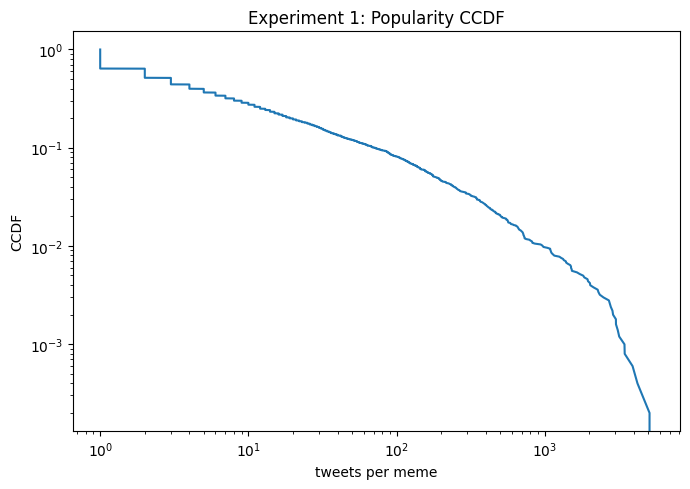

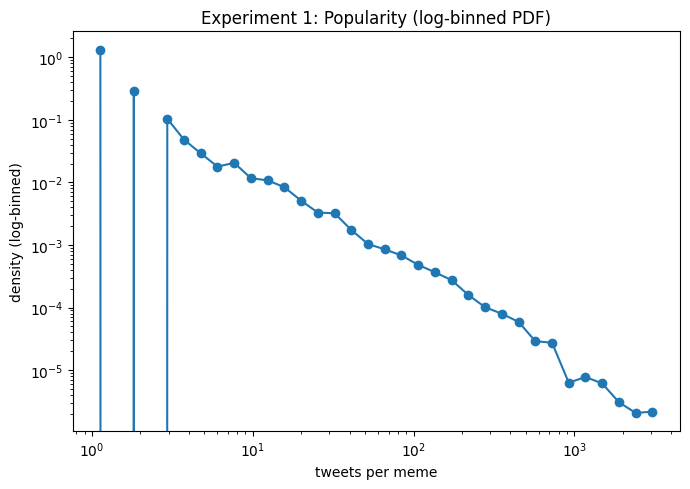

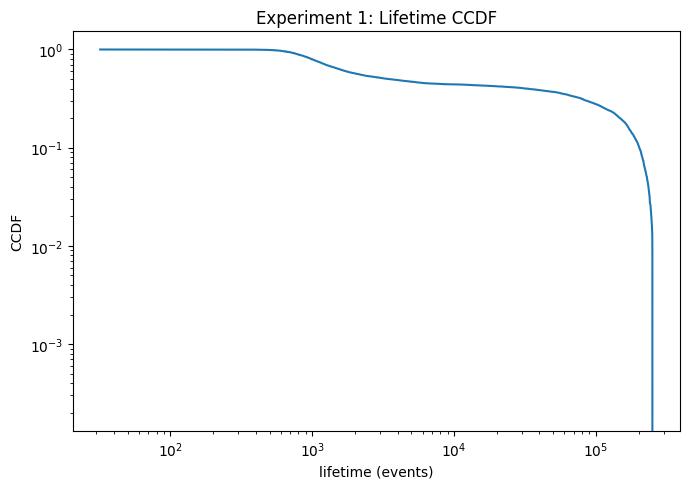

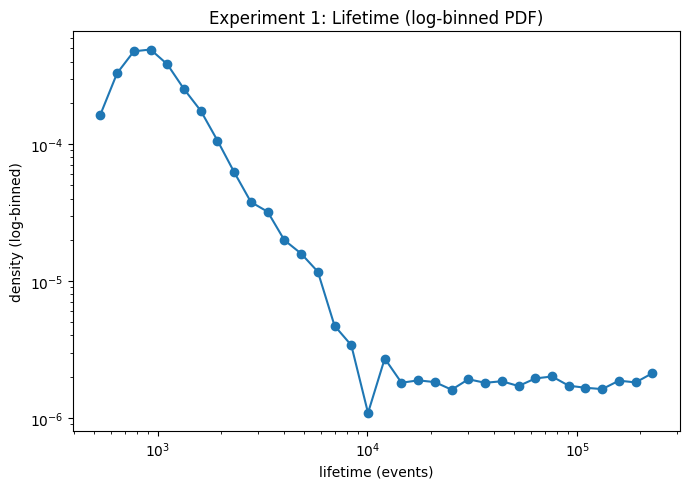

In [17]:
base_G = G_map["activity_homophily"]

res = run_weng_like(
    G=base_G,
    agent_ids=agent_ids,
    act_w=act_w,
    item_pool=item_pool,
    n_events=CFG["n_events"],
    alpha=CFG["alpha"],
    mu=CFG["mu"],
    recency_beta=CFG.get("recency_beta", 1.3),
    seed=RANDOM_SEED
)

pop = res["popularity"]
life = res["lifetime"]

print("observed_memes:", len(pop))
print("gini(popularity):", round(gini(pop), 4))
print("entropy(popularity):", round(entropy_counts(pop), 4))
print("median_lifetime:", int(np.median(life)) if len(life) else None)

life_died, life_cens = split_lifetimes(res, CFG["n_events"])
print("fraction_extinct:", round(len(life_died) / (len(life_died) + len(life_cens) + 1e-12), 4))
print("top1_share:", round(pop.max() / pop.sum(), 4))
print("top10_share:", round(np.sort(pop)[-10:].sum() / pop.sum(), 4))

plot_ccdf_loglog(pop, "Experiment 1: Popularity CCDF", "tweets per meme",
                 out_path=os.path.join(OUT_DIR, "exp1_pop_ccdf.png"))
plot_logbinned_pdf(pop, "Experiment 1: Popularity (log-binned PDF)", "tweets per meme",
                   out_path=os.path.join(OUT_DIR, "exp1_pop_pdf.png"))

plot_ccdf_loglog(life, "Experiment 1: Lifetime CCDF", "lifetime (events)",
                 out_path=os.path.join(OUT_DIR, "exp1_life_ccdf.png"))
plot_logbinned_pdf(life, "Experiment 1: Lifetime (log-binned PDF)", "lifetime (events)",
                   out_path=os.path.join(OUT_DIR, "exp1_life_pdf.png"))

memes_died: 2684 memes_censored: 2341
median_lifetime_died: 1163


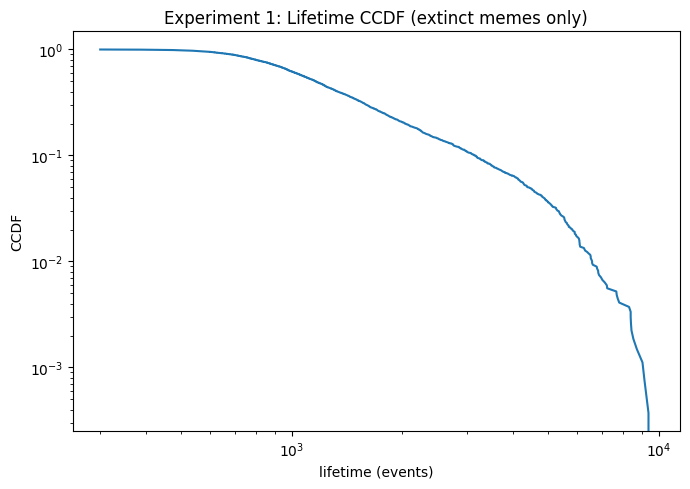

In [16]:
def split_lifetimes(res, n_events):
    births = res["births"]
    deaths = res["deaths"]
    died = []
    censored = []
    for m, b in births.items():
        d = deaths.get(m, n_events)
        lt = d - b
        if d < n_events:
            died.append(lt)
        else:
            censored.append(lt)
    return np.array(died, dtype=int), np.array(censored, dtype=int)

life_died, life_cens = split_lifetimes(res, CFG["n_events"])
print("memes_died:", len(life_died), "memes_censored:", len(life_cens))
if len(life_died) > 0:
    print("median_lifetime_died:", int(np.median(life_died)))
    plot_ccdf_loglog(
        life_died,
        "Experiment 1: Lifetime CCDF (extinct memes only)",
        "lifetime (events)",
        out_path=os.path.join(OUT_DIR, "exp1_life_ccdf_died.png")
    )

In [18]:
rows = []
for a in CFG["attention_sweep"]:
    for r in range(CFG["n_runs_per_setting"]):
        seed = RANDOM_SEED + 1000 * a + r
        res = run_weng_like(
            G=base_G,
            agent_ids=agent_ids,
            act_w=act_w,
            item_pool=item_pool,
            n_events=CFG["n_events"],
            alpha=a,
            mu=CFG["mu"],
            recency_beta=CFG.get("recency_beta", 1.3),
            seed=seed
        )
        pop = res["popularity"]
        life = res["lifetime"]
        life_died, life_cens = split_lifetimes(res, CFG["n_events"])
        frac_ext = len(life_died) / (len(life_died) + len(life_cens) + 1e-12)
        top1 = pop.max() / (pop.sum() + 1e-12)
        top10 = np.sort(pop)[-10:].sum() / (pop.sum() + 1e-12)

        rows.append({
            "alpha": a,
            "run": r,
            "gini_pop": gini(pop),
            "entropy_pop": entropy_counts(pop),
            "median_life": float(np.median(life)) if len(life) else np.nan,
            "p90_life": float(np.quantile(life, 0.9)) if len(life) else np.nan,
            "observed_memes": int(len(pop)),
            "frac_extinct": float(frac_ext),
            "top1_share": float(top1),
            "top10_share": float(top10)
        })
        print("done alpha", a, "run", r)

sweep = pd.DataFrame(rows)
sweep.to_csv(os.path.join(OUT_DIR, "exp2_attention_sweep.csv"), index=False)
sweep.groupby("alpha")[["gini_pop", "entropy_pop", "median_life", "p90_life", "observed_memes"]].mean().reset_index()

done alpha 5 run 0
done alpha 5 run 1
done alpha 5 run 2
done alpha 10 run 0
done alpha 10 run 1
done alpha 10 run 2
done alpha 20 run 0
done alpha 20 run 1
done alpha 20 run 2
done alpha 40 run 0
done alpha 40 run 1
done alpha 40 run 2


,alpha,gini_pop,entropy_pop,median_life,p90_life,observed_memes
0,5,0.880501,6.462138,25993.666667,210367.666667,5033.000000
1,10,0.896358,6.260086,3727.666667,202266.000000,5093.000000
2,20,0.904259,6.092664,4385.000000,195343.133333,5073.666667
3,40,0.908549,6.088192,7006.833333,186038.766667,5186.666667


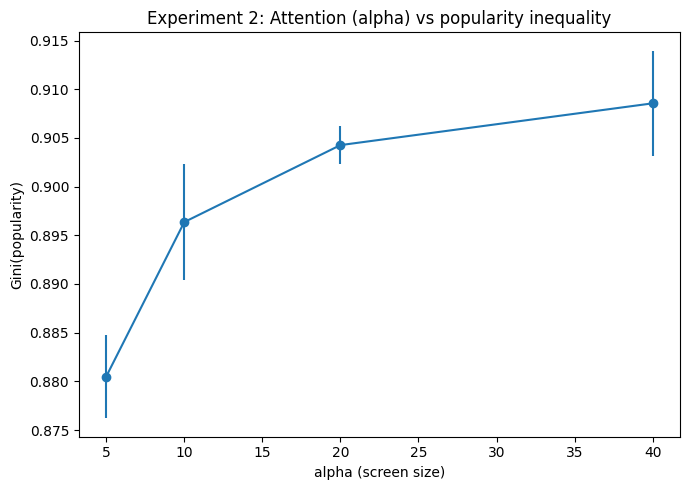

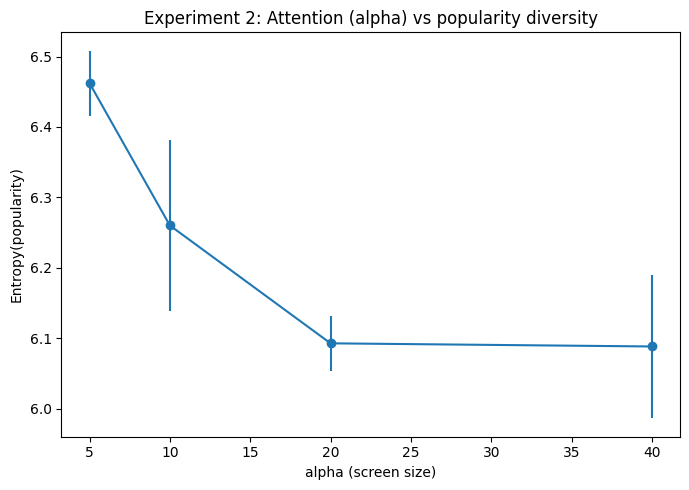

In [19]:
agg = sweep.groupby("alpha").agg(
    gini_pop=("gini_pop", "mean"),
    gini_std=("gini_pop", "std"),
    ent=("entropy_pop", "mean"),
    ent_std=("entropy_pop", "std"),
).reset_index()

plt.figure(figsize=(7, 5))
plt.errorbar(agg["alpha"], agg["gini_pop"], yerr=agg["gini_std"], marker="o", linewidth=1.5)
plt.title("Experiment 2: Attention (alpha) vs popularity inequality")
plt.xlabel("alpha (screen size)")
plt.ylabel("Gini(popularity)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "exp2_gini_vs_alpha.png"), dpi=220)
plt.show()

plt.figure(figsize=(7, 5))
plt.errorbar(agg["alpha"], agg["ent"], yerr=agg["ent_std"], marker="o", linewidth=1.5)
plt.title("Experiment 2: Attention (alpha) vs popularity diversity")
plt.xlabel("alpha (screen size)")
plt.ylabel("Entropy(popularity)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "exp2_entropy_vs_alpha.png"), dpi=220)
plt.show()

In [21]:
rows = []
for gname in CFG["graphs_to_compare"]:
    G = G_map[gname]
    for r in range(CFG["n_runs_per_setting"]):
        seed = RANDOM_SEED + 777 + 1000 * r + (abs(hash(gname)) % 1000)
        res = run_weng_like(
            G=G,
            agent_ids=agent_ids,
            act_w=act_w,
            item_pool=item_pool,
            n_events=CFG["n_events"],
            alpha=CFG["alpha"],
            mu=CFG["mu"],
            recency_beta=CFG.get("recency_beta", 1.3),
            seed=seed
        )
        pop = res["popularity"]
        life = res["lifetime"]
        life_died, life_cens = split_lifetimes(res, CFG["n_events"])
        frac_ext = len(life_died) / (len(life_died) + len(life_cens) + 1e-12)
        top1 = pop.max() / (pop.sum() + 1e-12)
        top10 = np.sort(pop)[-10:].sum() / (pop.sum() + 1e-12)

        rows.append({
            "graph": gname,
            "run": r,
            "gini_pop": gini(pop),
            "entropy_pop": entropy_counts(pop),
            "median_life": float(np.median(life)) if len(life) else np.nan,
            "p90_life": float(np.quantile(life, 0.9)) if len(life) else np.nan,
            "observed_memes": int(len(pop)),
            "frac_extinct": float(frac_ext),
            "top1_share": float(top1),
            "top10_share": float(top10)
        })
        print("done graph", gname, "run", r)

comp = pd.DataFrame(rows)
comp.to_csv(os.path.join(OUT_DIR, "exp3_network_compare.csv"), index=False)
comp.groupby("graph")[["gini_pop", "entropy_pop", "median_life", "p90_life", "observed_memes"]].mean().reset_index()


done graph activity_homophily run 0
done graph activity_homophily run 1
done graph activity_homophily run 2
done graph degree_randomized run 0
done graph degree_randomized run 1
done graph degree_randomized run 2
done graph influence_biased run 0
done graph influence_biased run 1
done graph influence_biased run 2


,graph,gini_pop,entropy_pop,median_life,p90_life,observed_memes
0,activity_homophily,0.896499,6.267427,3538.166667,203255.433333,5108.0
1,degree_randomized,0.908181,6.046026,2221.333333,188955.900000,5133.0
2,influence_biased,0.919380,5.799918,2203.666667,188280.666667,5040.0


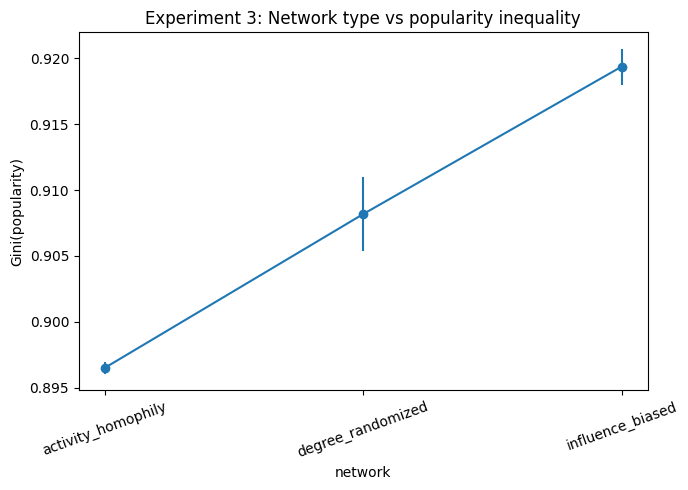

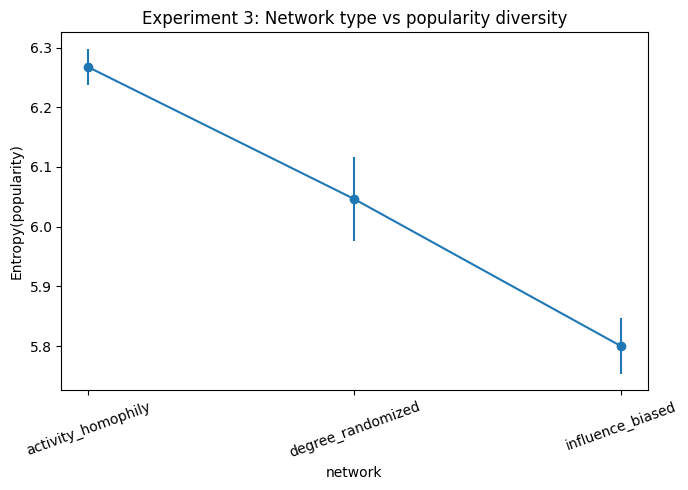

In [22]:
agg = comp.groupby("graph").agg(
    gini_pop=("gini_pop", "mean"),
    gini_std=("gini_pop", "std"),
    ent=("entropy_pop", "mean"),
    ent_std=("entropy_pop", "std")
).reset_index()

plt.figure(figsize=(7, 5))
plt.errorbar(agg["graph"], agg["gini_pop"], yerr=agg["gini_std"], marker="o", linewidth=1.5)
plt.title("Experiment 3: Network type vs popularity inequality")
plt.xlabel("network")
plt.ylabel("Gini(popularity)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "exp3_gini_by_graph.png"), dpi=220)
plt.show()

plt.figure(figsize=(7, 5))
plt.errorbar(agg["graph"], agg["ent"], yerr=agg["ent_std"], marker="o", linewidth=1.5)
plt.title("Experiment 3: Network type vs popularity diversity")
plt.xlabel("network")
plt.ylabel("Entropy(popularity)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "exp3_entropy_by_graph.png"), dpi=220)
plt.show()